In [21]:
import os

dataset_path = "/kaggle/input/datasets/dhawalsrivastava2583/flood-classification-dataset"

print(os.listdir(dataset_path))

['Dataset']


In [22]:
for path, dirs, files in os.walk(dataset_path):
    print("PATH:", path)

    for file in files[:5]:
        print("   ", file)

    print("-" * 50)

PATH: /kaggle/input/datasets/dhawalsrivastava2583/flood-classification-dataset
--------------------------------------------------
PATH: /kaggle/input/datasets/dhawalsrivastava2583/flood-classification-dataset/Dataset
--------------------------------------------------
PATH: /kaggle/input/datasets/dhawalsrivastava2583/flood-classification-dataset/Dataset/Non Flood Images
    20088.jpg
    3863.jpg
    6241.jpg
    2193.jpg
    2008.jpg
--------------------------------------------------
PATH: /kaggle/input/datasets/dhawalsrivastava2583/flood-classification-dataset/Dataset/Flood Images
    flood_1625.jpg
    flood_866.jpg
    flood_8278.png
    flood_8820.png
    flood_1987.jpg
--------------------------------------------------
PATH: /kaggle/input/datasets/dhawalsrivastava2583/flood-classification-dataset/Dataset/Annotation
    flood_21.json
    flood_119.json
    flood_60.json
    flood_118.json
    flood_12.json
--------------------------------------------------


In [23]:
import os

DATASET_PATH = "/kaggle/input/datasets/dhawalsrivastava2583/flood-classification-dataset/Dataset"

FLOOD_PATH = os.path.join(DATASET_PATH, "Flood Images")
NON_FLOOD_PATH = os.path.join(DATASET_PATH, "Non Flood Images")

print("Flood images:", len(os.listdir(FLOOD_PATH)))
print("Non-flood images:", len(os.listdir(NON_FLOOD_PATH)))

Flood images: 9296
Non-flood images: 3748


In [24]:
import os
import shutil
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm import tqdm

OUTPUT_PATH = "/kaggle/working/FloodRescueAI_Dataset"

classes = {
    "flood": FLOOD_PATH,
    "no_flood": NON_FLOOD_PATH
}

for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(OUTPUT_PATH, split, cls), exist_ok=True)

def valid_image(path):
    try:
        img = Image.open(path).convert("RGB")
        w, h = img.size
        if w < 100 or h < 100:
            return False
        return True
    except:
        return False

for cls, folder in classes.items():
    files = [
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    valid_files = []

    for f in tqdm(files, desc=f"Checking {cls}"):
        full_path = os.path.join(folder, f)
        if valid_image(full_path):
            valid_files.append(f)

    train_files, temp_files = train_test_split(
        valid_files,
        test_size=0.30,
        random_state=42
    )

    val_files, test_files = train_test_split(
        temp_files,
        test_size=0.50,
        random_state=42
    )

    split_data = {
        "train": train_files,
        "val": val_files,
        "test": test_files
    }

    for split, split_files in split_data.items():
        for i, f in enumerate(tqdm(split_files, desc=f"Copying {cls} {split}")):
            src = os.path.join(folder, f)
            dst = os.path.join(OUTPUT_PATH, split, cls, f"{cls}_{i}.jpg")

            img = Image.open(src).convert("RGB")
            img.save(dst)

print("Cleaning and splitting completed.")

Copying no_flood test: 100%|██████████| 563/563 [00:01<00:00, 539.14it/s]

Cleaning and splitting completed.


In [25]:
for split in ["train", "val", "test"]:
    print("\n", split.upper())
    for cls in ["flood", "no_flood"]:
        folder = os.path.join(OUTPUT_PATH, split, cls)
        print(cls, len(os.listdir(folder)))


 TRAIN
flood 6507
no_flood 2623

 VAL
flood 1394
no_flood 562

 TEST
flood 1395
no_flood 563


In [26]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

In [27]:
BASE_PATH = "/kaggle/working/FloodRescueAI_Dataset"

TRAIN_PATH = os.path.join(BASE_PATH, "train")
VAL_PATH = os.path.join(BASE_PATH, "val")
TEST_PATH = os.path.join(BASE_PATH, "test")

BATCH_SIZE = 32
IMG_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(DEVICE)

cuda


In [28]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [29]:
train_dataset = datasets.ImageFolder(TRAIN_PATH, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_PATH, transform=test_transform)
test_dataset = datasets.ImageFolder(TEST_PATH, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(train_dataset.classes)
print(train_dataset.class_to_idx)

['flood', 'no_flood']
{'flood': 0, 'no_flood': 1}


In [30]:
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

num_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, 2)
)

model = model.to(DEVICE)

In [31]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [32]:
def train_one_epoch(model, loader):
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(loader):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [33]:
def evaluate(model, loader):
    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(loader):
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [34]:
EPOCHS = 10
best_val_acc = 0

train_acc_list = []
val_acc_list = []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = evaluate(model, val_loader)

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "/kaggle/working/best_flood_efficientnet.pth")
        print("Best model saved")


Epoch 1/10


100%|██████████| 62/62 [00:26<00:00,  2.35it/s]


Train Loss: 0.0879 | Train Acc: 0.9763
Val Loss: 0.0029 | Val Acc: 0.9995
Best model saved

Epoch 2/10


100%|██████████| 62/62 [00:26<00:00,  2.37it/s]


Train Loss: 0.0124 | Train Acc: 0.9970
Val Loss: 0.0011 | Val Acc: 0.9995

Epoch 3/10


...

Train Loss: 0.0031 | Train Acc: 0.9992
Val Loss: 0.0004 | Val Acc: 1.0000

Epoch 9/10


100%|██████████| 62/62 [00:26<00:00,  2.37it/s]


Train Loss: 0.0035 | Train Acc: 0.9990
Val Loss: 0.0004 | Val Acc: 1.0000

Epoch 10/10


100%|██████████| 62/62 [00:26<00:00,  2.37it/s]

Train Loss: 0.0023 | Train Acc: 0.9991
Val Loss: 0.0005 | Val Acc: 1.0000


In [35]:
model.load_state_dict(torch.load("/kaggle/working/best_flood_efficientnet.pth"))

test_loss, test_acc = evaluate(model, test_loader)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

100%|██████████| 62/62 [00:25<00:00,  2.39it/s]

Test Loss: 0.0019630543857279154
Test Accuracy: 0.9989785495403473


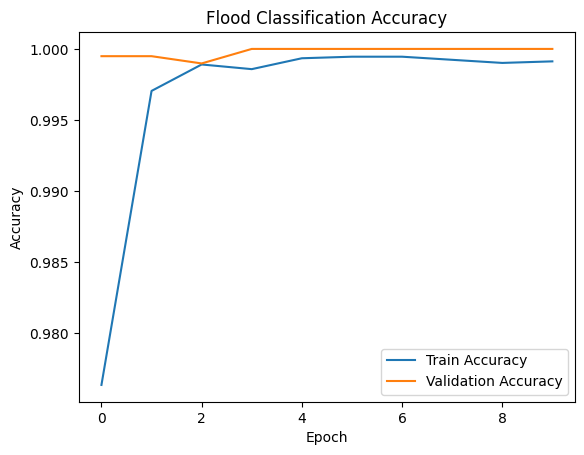

In [36]:
plt.plot(train_acc_list, label="Train Accuracy")
plt.plot(val_acc_list, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Flood Classification Accuracy")
plt.legend()
plt.show()

In [37]:
import json

class_info = {
    "classes": train_dataset.classes,
    "class_to_idx": train_dataset.class_to_idx
}

with open("/kaggle/working/class_names.json", "w") as f:
    json.dump(class_info, f)

print(class_info)

{'classes': ['flood', 'no_flood'], 'class_to_idx': {'flood': 0, 'no_flood': 1}}


In [38]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

print("\nClassification Report:")
print(classification_report(
    all_labels,
    all_preds,
    target_names=test_dataset.classes
))

100%|██████████| 62/62 [00:26<00:00,  2.33it/s]

Confusion Matrix:
[[1393    2]
 [   0  563]]

Classification Report:
              precision    recall  f1-score   support

       flood       1.00      1.00      1.00      1395
    no_flood       1.00      1.00      1.00       563

    accuracy                           1.00      1958
   macro avg       1.00      1.00      1.00      1958
weighted avg       1.00      1.00      1.00      1958



In [39]:
torch.save({
    "model_state_dict": model.state_dict(),
    "class_to_idx": train_dataset.class_to_idx,
    "classes": train_dataset.classes
}, "/kaggle/working/floodrescue_classification_model.pth")

print("Final model saved.")

Final model saved.


In [41]:
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import torch.nn.functional as F

In [42]:
model = models.efficientnet_b0(weights=None)

num_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, 2)
)

checkpoint = torch.load(
    "/kaggle/working/floodrescue_classification_model.pth",
    map_location=DEVICE
)

model.load_state_dict(checkpoint["model_state_dict"])

class_names = checkpoint["classes"]

model = model.to(DEVICE)
model.eval()

print(class_names)

['flood', 'no_flood']


In [43]:
predict_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [44]:
def predict_image(image_path):

    image = Image.open(image_path).convert("RGB")

    input_tensor = predict_transform(image)

    input_tensor = input_tensor.unsqueeze(0).to(DEVICE)

    with torch.no_grad():

        outputs = model(input_tensor)

        probabilities = F.softmax(outputs, dim=1)

        confidence, predicted_class = torch.max(probabilities, 1)

    predicted_label = class_names[predicted_class.item()]

    confidence_score = confidence.item() * 100

    plt.imshow(image)
    plt.axis("off")

    plt.title(
        f"Prediction: {predicted_label}\nConfidence: {confidence_score:.2f}%"
    )

    plt.show()

    return predicted_label, confidence_score

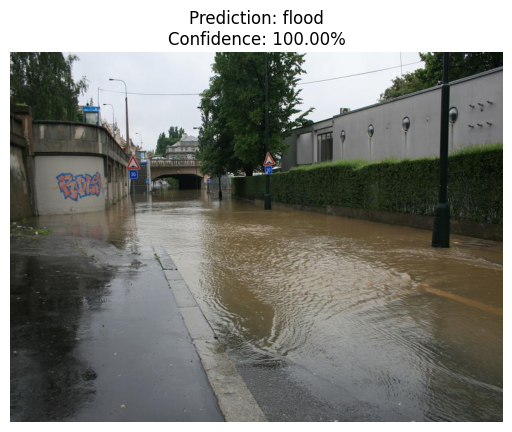

('flood', 99.99878406524658)

In [45]:
test_image = "/kaggle/input/datasets/dhawalsrivastava2583/flood-classification-dataset/Dataset/Flood Images/flood_21.jpg"

predict_image(test_image)

In [46]:
!pip install -q opencv-python

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [54]:
def estimate_flood_severity(image_path):

    image_bgr = cv2.imread(image_path)

    if image_bgr is None:
        print("Image not found")
        return None

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    hsv = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)

    lower_water = np.array([5, 20, 40])
    upper_water = np.array([40, 255, 220])

    mask = cv2.inRange(hsv, lower_water, upper_water)

    kernel = np.ones((7, 7), np.uint8)

    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    flood_pixels = np.sum(mask > 0)

    total_pixels = mask.shape[0] * mask.shape[1]

    flood_ratio = flood_pixels / total_pixels

    if flood_ratio < 0.15:
        severity = "Mild Flood"

    elif flood_ratio < 0.35:
        severity = "Moderate Flood"

    else:
        severity = "Severe Flood"

    overlay = image_rgb.copy()

    overlay[mask > 0] = [255, 0, 0]

    blended = cv2.addWeighted(image_rgb, 0.7, overlay, 0.3, 0)

    # =========================
    # SAVE OVERLAY IMAGE
    # =========================

    output_path = "/kaggle/working/flood_overlay_output.png"

    blended_bgr = cv2.cvtColor(blended, cv2.COLOR_RGB2BGR)

    cv2.imwrite(output_path, blended_bgr)

    print("Overlay image saved at:")
    print(output_path)

    # =========================
    # DISPLAY
    # =========================

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(image_rgb)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(mask, cmap="gray")
    plt.title("Detected Flood Area")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(blended)
    plt.title(f"{severity}\nFlood Area: {flood_ratio*100:.2f}%")
    plt.axis("off")

    plt.show()

    return severity, flood_ratio * 100

Overlay image saved at:
/kaggle/working/flood_overlay_output.png


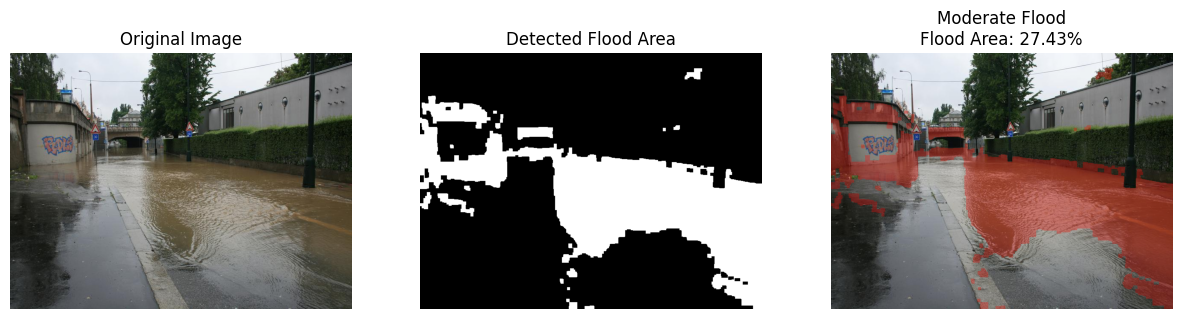

('Moderate Flood', np.float64(27.43375))

In [55]:
estimate_flood_severity(test_image)

In [56]:
def floodrescue_ai_prediction(image_path):
    predicted_label, confidence = predict_image(image_path)

    if predicted_label == "flood":
        severity, flood_area = estimate_flood_severity(image_path)
        flood_area = float(flood_area)
    else:
        severity = "No Flood Risk"
        flood_area = 0.0

    result = {
        "prediction": predicted_label,
        "confidence": float(round(confidence, 2)),
        "severity": severity,
        "estimated_flood_area_percentage": float(round(flood_area, 2))
    }

    return result

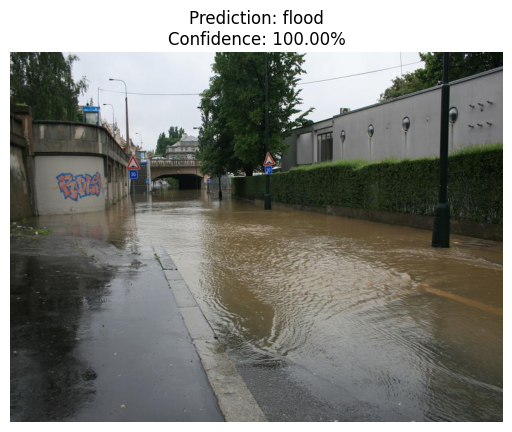

Overlay image saved at:
/kaggle/working/flood_overlay_output.png


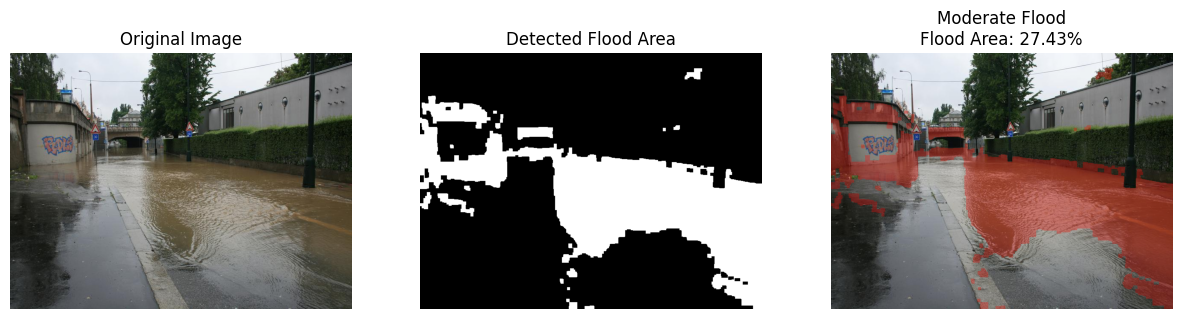

{'prediction': 'flood',
 'confidence': 100.0,
 'severity': 'Moderate Flood',
 'estimated_flood_area_percentage': 27.43}

In [57]:
result = floodrescue_ai_prediction(test_image)

result

In [58]:
torch.save({
    "model_state_dict": model.state_dict(),
    "class_to_idx": train_dataset.class_to_idx,
    "classes": train_dataset.classes
}, "/kaggle/working/floodrescue_classification_model.pth")

print("Model saved")

Model saved


In [59]:
import os

for item in os.listdir("/kaggle/input"):
    print(item)

datasets


In [62]:
seg_path = "/kaggle/input/datasets/faizalkarim/flood-area-segmentation"

for path, dirs, files in os.walk(seg_path):
    print("PATH:", path)
    for file in files[:5]:
        print("   ", file)
    print("-" * 50)

PATH: /kaggle/input/datasets/faizalkarim/flood-area-segmentation
    metadata.csv
--------------------------------------------------
PATH: /kaggle/input/datasets/faizalkarim/flood-area-segmentation/Mask
    1017.png
    2015.png
    1084.png
    2021.png
    1012.png
--------------------------------------------------
PATH: /kaggle/input/datasets/faizalkarim/flood-area-segmentation/Image
    2008.jpg
    1075.jpg
    2029.jpg
    1031.jpg
    2021.jpg
--------------------------------------------------


In [67]:
SEG_ROOT = "/kaggle/input/datasets/faizalkarim/flood-area-segmentation"
IMAGE_DIR = SEG_ROOT + "/Image"
MASK_DIR = SEG_ROOT + "/Mask"

In [70]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
from tqdm import tqdm

In [73]:
class FloodSegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, img_size=256):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.img_size = img_size

        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        image_path = os.path.join(self.image_dir, img_name)

        mask_name = img_name.replace(".jpg", ".png")
        mask_path = os.path.join(self.mask_dir, mask_name)

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        image = cv2.resize(image, (self.img_size, self.img_size))
        mask = cv2.resize(mask, (self.img_size, self.img_size))

        image = image / 255.0
        mask = mask / 255.0

        mask = (mask > 0.5).astype(np.float32)

        image = np.transpose(image, (2, 0, 1)).astype(np.float32)
        mask = np.expand_dims(mask, axis=0).astype(np.float32)

        return torch.tensor(image), torch.tensor(mask)

In [74]:
dataset = FloodSegmentationDataset(IMAGE_DIR, MASK_DIR, img_size=256)

print("Total samples:", len(dataset))

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_seg_dataset, val_seg_dataset = random_split(dataset, [train_size, val_size])

train_seg_loader = DataLoader(train_seg_dataset, batch_size=8, shuffle=True)
val_seg_loader = DataLoader(val_seg_dataset, batch_size=8, shuffle=False)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

Total samples: 290
Device: cuda


In [76]:
class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()

        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, 3, padding=1),
                nn.ReLU(inplace=True)
            )

        self.enc1 = conv_block(3, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = conv_block(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = conv_block(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = conv_block(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = conv_block(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = conv_block(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = conv_block(128, 64)

        self.final = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))

        b = self.bottleneck(self.pool3(e3))

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)

In [77]:
seg_model = UNet().to(DEVICE)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(seg_model.parameters(), lr=1e-4)

In [78]:
EPOCHS = 10
best_val_loss = float("inf")

for epoch in range(EPOCHS):
    seg_model.train()
    train_loss = 0

    for images, masks in tqdm(train_seg_loader):
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()

        outputs = seg_model(images)
        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss = train_loss / len(train_seg_loader)

    seg_model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, masks in val_seg_loader:
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            outputs = seg_model(images)
            loss = criterion(outputs, masks)

            val_loss += loss.item()

    val_loss = val_loss / len(val_seg_loader)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(seg_model.state_dict(), "/kaggle/working/best_flood_unet.pth")
        print("Best U-Net model saved")

100%|██████████| 29/29 [00:19<00:00,  1.50it/s]


Epoch 1/10
Train Loss: 0.6811
Val Loss: 0.6731
Best U-Net model saved


100%|██████████| 29/29 [00:17<00:00,  1.62it/s]


Epoch 2/10
Train Loss: 0.5882
Val Loss: 0.5303
Best U-Net model saved


100%|██████████| 29/29 [00:17<00:00,  1.68it/s]


...

Epoch 8/10
Train Loss: 0.4519
Val Loss: 0.3580
Best U-Net model saved


100%|██████████| 29/29 [00:17<00:00,  1.64it/s]


Epoch 9/10
Train Loss: 0.4213
Val Loss: 0.3539
Best U-Net model saved


100%|██████████| 29/29 [00:17<00:00,  1.63it/s]


Epoch 10/10
Train Loss: 0.4120
Val Loss: 0.3864


In [79]:
seg_model = UNet().to(DEVICE)

seg_model.load_state_dict(
    torch.load("/kaggle/working/best_flood_unet.pth", map_location=DEVICE)
)

seg_model.eval()

print("U-Net loaded successfully")

U-Net loaded successfully


In [80]:
def segment_flood_area(image_path, save_path="/kaggle/working/unet_flood_overlay.png"):
    image_bgr = cv2.imread(image_path)

    if image_bgr is None:
        print("Image not found")
        return None

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    original_h, original_w = image_rgb.shape[:2]

    resized = cv2.resize(image_rgb, (256, 256))
    normalized = resized / 255.0

    tensor = np.transpose(normalized, (2, 0, 1)).astype(np.float32)
    tensor = torch.tensor(tensor).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = seg_model(tensor)
        output = torch.sigmoid(output)

    mask = output.squeeze().cpu().numpy()
    mask = (mask > 0.5).astype(np.uint8)

    mask_resized = cv2.resize(mask, (original_w, original_h))

    flood_pixels = np.sum(mask_resized > 0)
    total_pixels = original_h * original_w
    flood_percentage = (flood_pixels / total_pixels) * 100

    if flood_percentage < 15:
        severity = "Mild Flood"
    elif flood_percentage < 35:
        severity = "Moderate Flood"
    else:
        severity = "Severe Flood"

    overlay = image_rgb.copy()
    overlay[mask_resized > 0] = [255, 0, 0]

    blended = cv2.addWeighted(image_rgb, 0.7, overlay, 0.3, 0)

    blended_bgr = cv2.cvtColor(blended, cv2.COLOR_RGB2BGR)
    cv2.imwrite(save_path, blended_bgr)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(image_rgb)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask_resized, cmap="gray")
    plt.title("U-Net Predicted Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(blended)
    plt.title(f"{severity}\nFlood Area: {flood_percentage:.2f}%")
    plt.axis("off")

    plt.show()

    result = {
        "segmentation_overlay_path": save_path,
        "flood_area_percentage": float(round(flood_percentage, 2)),
        "severity": severity
    }

    return result

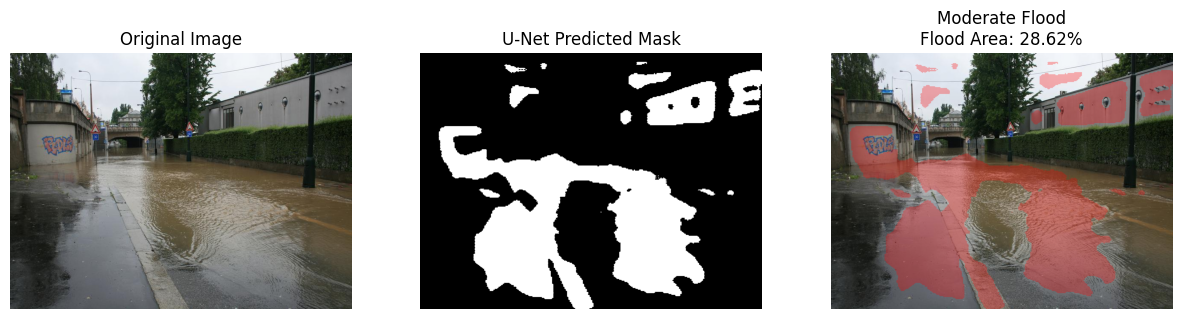

{'segmentation_overlay_path': '/kaggle/working/unet_flood_overlay.png',
 'flood_area_percentage': 28.62,
 'severity': 'Moderate Flood'}

In [81]:
segment_result = segment_flood_area(test_image)

segment_result

In [82]:
torch.save({
    "model_state_dict": seg_model.state_dict(),
    "image_size": 256
}, "/kaggle/working/floodrescue_segmentation_unet.pth")

print("Final segmentation model saved")

Final segmentation model saved
